In [1]:
import parcels
import numpy as np
from datetime import timedelta
from glob import glob
import matplotlib.pyplot as plt
import xarray as xr
import os

def u2rho_2d (var_u):
    [Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[:,1:L-1]=0.5*(var_u[:,0:Lm-1]+var_u[:,1:L-1])
    var_rho[:,0]=var_rho[:,1]
    var_rho[:,Lp-1]=var_rho[:,-2]
    return var_rho
    
def v2rho_2d (var_v):
    [M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[1:M-1,:]=0.5*(var_v[0:Mm-1,:]+var_v[1:M-1,:])
    var_rho[0,:]=var_rho[1,:]
    var_rho[Mp-1,:]=var_rho[-2,:]
    return var_rho

def u2rho_3d (var_u):
    [N,Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,:,1:L-1]=0.5*(var_u[:,:,0:Lm-1]+var_u[:,:,1:L-1])
    var_rho[:,:,0]=var_rho[:,:,1]
    var_rho[:,:,Lp-1]=var_rho[:,:,-2]
    return var_rho
    
def v2rho_3d (var_v):
    [N,M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,1:M-1,:]=0.5*(var_v[:,0:Mm-1,:]+var_v[:,1:M-1,:])
    var_rho[:,0,:]=var_rho[:,1,:]
    var_rho[:,Mp-1,:]=var_rho[:,-2,:]
    return var_rho

def spheric_dist(lat1, lat2, lon1, lon2):
    """
    Compute the spherical distance between two points on Earth.
    
    Parameters:
    lat1, lat2 : array-like
        Latitude of the two points (in degrees).
    lon1, lon2 : array-like
        Longitude of the two points (in degrees).
    
    Returns:
    dist : array-like
        The spherical distance between the points (in meters).
    """
    
    # Earth radius in meters
    R = 6367442.76
    
    # Determine proper longitudinal shift
    l = np.abs(lon2 - lon1)
    l[l >= 180] = 360 - l[l >= 180]
    
    # Convert decimal degrees to radians
    deg2rad = np.pi / 180
    lat1 = lat1 * deg2rad
    lat2 = lat2 * deg2rad
    l = l * deg2rad
    
    # Compute the distances
    dist = R * np.arcsin(np.sqrt(((np.sin(l) * np.cos(lat2)) ** 2) + 
                                 ((np.sin(lat2) * np.cos(lat1)) - 
                                  (np.sin(lat1) * np.cos(lat2) * np.cos(l))) ** 2))
    
    return dist

def spheric_dist_one(lat1, lat2, lon1, lon2):
    """计算两个经纬度点之间的球面距离（标量版）"""
    # 处理经度差
    l = np.abs(lon2 - lon1)
    if l >= 180:
        l = 360 - l
    
    # 转换为弧度
    deg2rad = np.pi / 180
    lat1_rad = lat1 * deg2rad
    lat2_rad = lat2 * deg2rad
    l_rad = l * deg2rad
    
    # 球面距离公式
    distance = 6371 * np.arccos(
        np.sin(lat1_rad) * np.sin(lat2_rad) + 
        np.cos(lat1_rad) * np.cos(lat2_rad) * np.cos(l_rad)
    )
    return distance

In [2]:
grid_dir='/meddy/simingzhang/Data/RB_iceland_data/'
wave_dir='/meddy/simingzhang/Data/Parcels_data/'
# nowave_dir='/meddy/simingzhang/Data/RB_iceland_data/iceland_no_wave/'
grdname='niskin2km_500m_grd.nc'
# hisname_w='z_niskin2km_his_hf_depth_500m_grd.0002.nc'
# hisname_nw='z_niskin2km_his_smooth_depth_500m_grd.0002.nc'

grdname=f'{grid_dir}{grdname}'
# wavename=f'{wave_dir}{hisname_w}'
# nowavename=f'{nowave_dir}{hisname_nw}'

wavename=f'{wave_dir}wavecase_modified.nc'
nowavename=f'{wave_dir}nowavecase_modified.nc'


In [3]:
grid=xr.open_dataset(grdname)
grid = grid.swap_dims({'eta_u': 'eta_rho','xi_v':'xi_rho'})

lon_rho=grid['lon_rho']
lat_rho=grid['lat_rho']
h=grid['h']
lonmin=np.min(lon_rho.values)
lonmax=np.max(lon_rho.values)
latmin=np.min(lat_rho.values)
latmax=np.max(lat_rho.values)
lonmin,lonmax,latmin,latmax
grid

<xarray.Dataset> Size: 19MB
Dimensions:    (one: 1, eta_rho: 287, xi_rho: 287, bath: 1, xi_u: 286,
                eta_v: 286, eta_psi: 286, xi_psi: 286)
Dimensions without coordinates: one, eta_rho, xi_rho, bath, xi_u, eta_v,
                                eta_psi, xi_psi
Data variables: (12/34)
    xl         (one) float64 8B ...
    el         (one) float64 8B ...
    depthmin   (one) float64 8B ...
    depthmax   (one) float64 8B ...
    spherical  (one) |S1 1B ...
    angle      (eta_rho, xi_rho) float64 659kB ...
    ...         ...
    lat_v      (eta_v, xi_rho) float64 657kB ...
    lat_psi    (eta_psi, xi_psi) float64 654kB ...
    mask_rho   (eta_rho, xi_rho) float64 659kB ...
    mask_u     (eta_rho, xi_u) float64 657kB ...
    mask_v     (eta_v, xi_rho) float64 657kB ...
    mask_psi   (eta_psi, xi_psi) float64 654kB ...
Attributes:
    title:    Solomon Model
    date:     08-Apr-2018
    type:     ROMS grid file

In [4]:
ds = xr.open_dataset(f'{wave_dir}wavecase.nc')
ds
depth=ds['depth'].values

In [5]:
ds = xr.open_dataset(f'{wave_dir}wavecase.nc')

ds['lon_rho']=lon_rho
ds['lat_rho']=lat_rho

ds.squeeze(dim='depth')
ds

<xarray.Dataset> Size: 2GB
Dimensions:     (depth: 1, time: 2148, eta_rho: 287, xi_u: 286, eta_v: 286,
                 xi_rho: 287)
Coordinates:
  * depth       (depth) float32 4B -2.0
Dimensions without coordinates: time, eta_rho, xi_u, eta_v, xi_rho
Data variables:
    ocean_time  (time) float32 9kB ...
    u           (time, depth, eta_rho, xi_u) float32 705MB ...
    v           (time, depth, eta_v, xi_rho) float32 705MB ...
    w           (time, depth, eta_rho, xi_rho) float32 708MB ...
    lon_rho     (eta_rho, xi_rho) float64 659kB -30.93 -30.89 ... -19.99 -19.95
    lat_rho     (eta_rho, xi_rho) float64 659kB 57.6 57.59 57.59 ... 61.39 61.38
Attributes:
    history:                   Thu Jul 18 14:58:06 2019: ncrcat -d depth,0 z_...
    nco_openmp_thread_number:  1

In [24]:
u_rho = np.zeros(ds['w'].shape)
u_rho[:,0,:,:]=u2rho_3d(np.squeeze(ds['u'].values))
# u_rho[np.abs(u_rho)<1e-3]=np.nan
ds["u_rho"] = (("time", "depth", "eta_rho", "xi_rho"), u_rho)
v_rho = np.zeros(ds['w'].shape)
v_rho[:,0,:,:]=v2rho_3d(np.squeeze(ds['v'].values))
# v_rho[np.abs(v_rho)<1e-3]=np.nan
ds["v_rho"] = (("time", "depth", "eta_rho", "xi_rho"), v_rho)

In [7]:
import scipy.io as sio
scale=[2,4,6,8,10,12,16,20,30,50,60,100]
# scale=[2,100]

PIW=np.zeros((len(scale)))
PINW=np.zeros((len(scale)))

i=0
for xscale in scale:
    wavename="/meddy/simingzhang/Data/RB_iceland_data/iceland_wave/filterdatawavehann{}km.nc_.mat".format(xscale)
    nowavename="/meddy/simingzhang/Data/RB_iceland_data/iceland_no_wave/filter_nc_mat/filterdatanowavehann{}km.nc_.mat".format(xscale)
    print(wavename)
    print(nowavename)
    datawave=sio.loadmat(wavename)
    datanowave=sio.loadmat(nowavename)
    PIW[i]=np.nanmean(datawave['PI'])
    # PI = np.zeros(ds['w'].shape)
    # PI[:,0,:,:]=datawave['PI']
    # ds[f"PI{xscale}"] = (("time", "depth", "eta_rho", "xi_rho"), PI)
    # del PI
    PINW[i]=np.nanmean(datanowave['PI'])
    i=i+1

/meddy/simingzhang/Data/RB_iceland_data/iceland_wave/filterdatawavehann2km.nc_.mat
/meddy/simingzhang/Data/RB_iceland_data/iceland_no_wave/filter_nc_mat/filterdatanowavehann2km.nc_.mat
/meddy/simingzhang/Data/RB_iceland_data/iceland_wave/filterdatawavehann4km.nc_.mat
/meddy/simingzhang/Data/RB_iceland_data/iceland_no_wave/filter_nc_mat/filterdatanowavehann4km.nc_.mat
/meddy/simingzhang/Data/RB_iceland_data/iceland_wave/filterdatawavehann6km.nc_.mat
/meddy/simingzhang/Data/RB_iceland_data/iceland_no_wave/filter_nc_mat/filterdatanowavehann6km.nc_.mat
/meddy/simingzhang/Data/RB_iceland_data/iceland_wave/filterdatawavehann8km.nc_.mat
/meddy/simingzhang/Data/RB_iceland_data/iceland_no_wave/filter_nc_mat/filterdatanowavehann8km.nc_.mat
/meddy/simingzhang/Data/RB_iceland_data/iceland_wave/filterdatawavehann10km.nc_.mat
/meddy/simingzhang/Data/RB_iceland_data/iceland_no_wave/filter_nc_mat/filterdatanowavehann10km.nc_.mat
/meddy/simingzhang/Data/RB_iceland_data/iceland_wave/filterdatawavehann12

In [8]:
import scipy.io as sio
sio.savemat('CG_hanning.mat',{'PIW':PIW,'PINW':PINW,'xscale':scale})

In [16]:
np.nanmean(ds['PI2'].values),np.nanmean(ds['PI100'].values),np.nanmean(ds['PI16'].values)

(0.0, -4.426001137595388e-09, -5.240750138456889e-10)

In [17]:
# PIW,
PI.shape

(2148, 1, 287, 287)

In [18]:
ds.to_netcdf(f'{wave_dir}wavecase_modified_cg.nc')

# spec

In [41]:
u_rho.shape

(2148, 1, 287, 287)

In [58]:
ni=150
nj=50
u1 = u_rho[:,0,nj,ni]
v1 = v_rho[:,0,nj,ni]

In [59]:
u1.shape

(2148,)

In [60]:
from scipy.fft import fft, fftfreq
from scipy.signal import welch, periodogram

In [61]:
N=len(u1)
yf1 = fft(u1*np.hanning(N))
yf2 = fft(v1*np.hanning(N))
xf = fftfreq(N, 1)

# 计算幅度谱
magnitude = 0.5*(np.abs(yf1)+np.abs(yf2))
f=4*np.pi*np.sin(np.pi*60/180)*366.25/(24*3600*365.25)*3600/2/np.pi


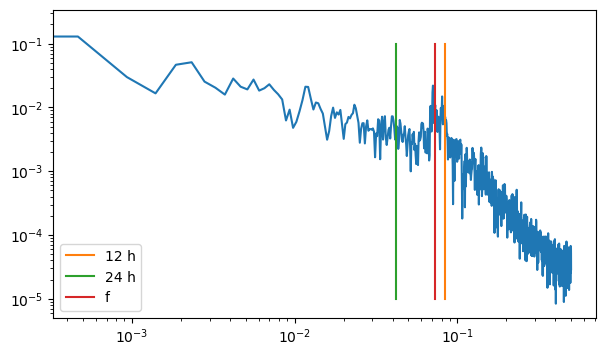

In [63]:
# 绘制频谱
plt.figure(figsize=(7, 4))
plt.loglog(xf[:N//2], 2.0/N * magnitude[:N//2])  # 只显示正频率部分
plt.plot([1/12,1/12],[1e-5,1e-1],label='12 h')
plt.plot([1/24,1/24],[1e-5,1e-1],label='24 h')
plt.plot([f,f],[1e-5,1e-1],label='f')
plt.legend(loc=3)

In [31]:
ds = xr.open_dataset(f'{wave_dir}nowavecase.nc')

ds['lon_rho']=lon_rho
ds['lat_rho']=lat_rho

ds.squeeze(dim='depth')
ds

<xarray.Dataset> Size: 2GB
Dimensions:     (depth: 1, time: 2148, eta_rho: 287, xi_u: 286, eta_v: 286,
                 xi_rho: 287)
Coordinates:
  * depth       (depth) float32 4B -2.0
Dimensions without coordinates: time, eta_rho, xi_u, eta_v, xi_rho
Data variables:
    ocean_time  (time) float32 9kB ...
    u           (time, depth, eta_rho, xi_u) float32 705MB ...
    v           (time, depth, eta_v, xi_rho) float32 705MB ...
    w           (time, depth, eta_rho, xi_rho) float32 708MB ...
    lon_rho     (eta_rho, xi_rho) float64 659kB -30.93 -30.89 ... -19.99 -19.95
    lat_rho     (eta_rho, xi_rho) float64 659kB 57.6 57.59 57.59 ... 61.39 61.38
Attributes:
    history:                   Tue Aug  6 19:53:40 2019: ncrcat -d depth,0 z_...
    nco_openmp_thread_number:  1

In [32]:
u_rho = np.zeros(ds['w'].shape)
u_rho[:,0,:,:]=u2rho_3d(np.squeeze(ds['u'].values))
ds["u_rho"] = (("time", "depth", "eta_rho", "xi_rho"), u_rho)
v_rho = np.zeros(ds['w'].shape)
v_rho[:,0,:,:]=v2rho_3d(np.squeeze(ds['v'].values))
ds["v_rho"] = (("time", "depth", "eta_rho", "xi_rho"), v_rho)

In [33]:
import scipy.io as sio
scale=[2,4,6,8,10,12,16,20,30,50,60,100]
# scale=[2,100]

# PIW=np.zeros((len(scale)))
PINW=np.zeros((len(scale)))

i=0
for xscale in scale:
    wavename="/meddy/simingzhang/Data/RB_iceland_data/iceland_wave/filterdatawavehann{}km.nc_.mat".format(xscale)
    nowavename="/meddy/simingzhang/Data/RB_iceland_data/iceland_no_wave/filter_nc_mat/filterdatanowavehann{}km.nc_.mat".format(xscale)
    print(nowavename)
    # datawave=sio.loadmat(wavename)
    datanowave=sio.loadmat(nowavename)
    PINW[i]=np.nanmean(datanowave['PI'])
    PI = np.zeros(ds['w'].shape)
    PI[:,0,:,:]=datanowave['PI']
    ds[f"PI{xscale}"] = (("time", "depth", "eta_rho", "xi_rho"), PI)
    # del PI

    i=i+1

/meddy/simingzhang/Data/RB_iceland_data/iceland_no_wave/filter_nc_mat/filterdatanowavehann2km.nc_.mat
/meddy/simingzhang/Data/RB_iceland_data/iceland_no_wave/filter_nc_mat/filterdatanowavehann4km.nc_.mat
/meddy/simingzhang/Data/RB_iceland_data/iceland_no_wave/filter_nc_mat/filterdatanowavehann6km.nc_.mat
/meddy/simingzhang/Data/RB_iceland_data/iceland_no_wave/filter_nc_mat/filterdatanowavehann8km.nc_.mat
/meddy/simingzhang/Data/RB_iceland_data/iceland_no_wave/filter_nc_mat/filterdatanowavehann10km.nc_.mat
/meddy/simingzhang/Data/RB_iceland_data/iceland_no_wave/filter_nc_mat/filterdatanowavehann12km.nc_.mat
/meddy/simingzhang/Data/RB_iceland_data/iceland_no_wave/filter_nc_mat/filterdatanowavehann16km.nc_.mat
/meddy/simingzhang/Data/RB_iceland_data/iceland_no_wave/filter_nc_mat/filterdatanowavehann20km.nc_.mat
/meddy/simingzhang/Data/RB_iceland_data/iceland_no_wave/filter_nc_mat/filterdatanowavehann30km.nc_.mat
/meddy/simingzhang/Data/RB_iceland_data/iceland_no_wave/filter_nc_mat/filterd

In [34]:
ds.to_netcdf(f'{wave_dir}nowavecase_modified_cg.nc')

In [15]:
# del dsw

In [3]:
dsnw=xr.open_dataset('/meddy/simingzhang/Data/RB_iceland_data/iceland_no_wave/z_niskin2km_his_smooth_depth_500m_grd.0002.nc')

In [4]:
ocean_time=dsnw['ocean_time']

In [5]:
dsw=xr.open_dataset('/meddy/simingzhang/Data/RB_iceland_data/iceland_wave/z_niskin2km_his_hf_depth_500m_grd.0002.nc')

In [6]:
dsw['ocean_time']=ocean_time

In [7]:
dsw

<xarray.Dataset> Size: 2GB
Dimensions:     (depth: 1, time: 2148, eta_rho: 287, xi_u: 286, eta_v: 286,
                 xi_rho: 287)
Coordinates:
  * depth       (depth) float32 4B -2.0
Dimensions without coordinates: time, eta_rho, xi_u, eta_v, xi_rho
Data variables:
    ocean_time  (time) float32 9kB ...
    u           (time, depth, eta_rho, xi_u) float32 705MB ...
    v           (time, depth, eta_v, xi_rho) float32 705MB ...
    w           (time, depth, eta_rho, xi_rho) float32 708MB ...
Attributes:
    history:                   Thu Jul 18 14:58:06 2019: ncrcat -d depth,0 z_...
    nco_openmp_thread_number:  1

In [8]:
dsw.to_netcdf('/meddy/simingzhang/Data/Parcels_data/wavecase.nc')

# plot cg

In [5]:
import scipy.io as sio
scale=[2,4,6,8,10,12,16,20,30,50,60,100]
# scale=[2,100]

PIW=np.zeros((len(scale)))
PINW=np.zeros((len(scale)))

i=0
for xscale in scale:
    wavename="/meddy/simingzhang/Data/RB_iceland_data/iceland_wave/filterdatawavehann{}km.nc_.mat".format(xscale)
    # nowavename="/meddy/simingzhang/Data/RB_iceland_data/iceland_no_wave/filter_nc_mat/filterdatanowavehann{}km.nc_.mat".format(xscale)
    print(wavename)
    datawave=sio.loadmat(wavename)
    datanowave=sio.loadmat(nowavename)
    PIW[i]=np.nanmean(datawave['PI'])
    # PI = np.zeros(ds['w'].shape)
    # PI[:,0,:,:]=datawave['PI']
    # ds[f"PI{xscale}"] = (("time", "depth", "eta_rho", "xi_rho"), PI)
    # del PI
    PINW[i]=np.nanmean(datanowave['PI'])
    i=i+1

/meddy/simingzhang/Data/RB_iceland_data/iceland_wave/filterdatawavehann2km.nc_.mat


ValueError: Unknown mat file type, version 0, 0